# Manual Verification of Lump Model Computation

This notebook implements the operations executed by `lump_numba` computation step-by- for single parameter values.

**Purpose**: Verify manually single combinations of parameters and understand the computation flow.

## Block 1: Define All Input Parameters

Set all input parameters needed for the lump model computation.

In [1]:
import numpy as np
import sys
from pathlib import Path
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_repo_root = next((p for p in _candidates if (p / "src").is_dir()), None)
if _repo_root is not None and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# ============================================================================
# PHYSICAL CONSTANTS
# ============================================================================

# Tritium decay constant (s^-1)
lambda_T = np.log(2) / (12.32 * 365.25 * 24 * 3600)  # Half-life = 12.32 years

# Tritium atomic mass (kg)
tritium_mass = 3.016 * 1.66054e-27  # 3 AMU in kg
joule_to_GWh = 1/3.6e12  # Conversion factor from Joules to GWh

# Fusion reaction energies (J)
E_DDp = 4.03e6 * 1.60218e-19    # DD→³He+n: 4.03 MeV
E_DDn = 3.27e6 * 1.60218e-19    # DD→T+p: 3.27 MeV
E_DT = 17.6e6 * 1.60218e-19     # DT→⁴He+n: 17.6 MeV
E_DHe3 = 18.3e6 * 1.60218e-19   # D³He→⁴He+p: 18.3 MeV

print("Physical Constants Defined:")
print(f"  λ_T (tritium decay constant) = {lambda_T:.6e} s⁻¹")
print(f"  Tritium mass = {tritium_mass:.6e} kg")
print(f"  E_DDp = {E_DDp:.6e} J")
print(f"  E_DDn = {E_DDn:.6e} J")
print(f"  E_DT = {E_DT:.6e} J")
print(f"  E_DHe3 = {E_DHe3:.6e} J")
print()

Physical Constants Defined:
  λ_T (tritium decay constant) = 1.782834e-09 s⁻¹
  Tritium mass = 5.008189e-27 kg
  E_DDp = 6.456785e-13 J
  E_DDn = 5.239129e-13 J
  E_DT = 2.819837e-12 J
  E_DHe3 = 2.931989e-12 J



In [2]:
# ============================================================================
# PLASMA PARAMETERS
# ============================================================================

V_plasma = 150.0                # Plasma volume (m³)
T_i = 14.0                      # Ion temperature (keV)
n_tot = 1.7e20                 # Total particle density (m⁻³)
tau_p_T = 1                   # Tritium confinement time (s)
tau_p_He3 = 1.0                 # Helium-3 confinement time (s)

print("Plasma Parameters:")
print(f"  V_plasma = {V_plasma} m³")
print(f"  T_i = {T_i} keV")
print(f"  n_tot = {n_tot:.2e} m⁻³")
print(f"  τ_p_T = {tau_p_T} s")
print(f"  τ_p_He3 = {tau_p_He3} s")
print()

# ============================================================================
# CALCULATE REACTION RATE COEFFICIENTS (⟨σv⟩) using Bosch-Hale formulas
# ============================================================================
# These are calculated at the ion temperature T_i using physics functions
from src.physics.reactivity_functions import (
    sigmav_DT_BoschHale,
    sigmav_DD_BoschHale,
    sigmav_DHe3_BoschHale
)

sigmav_DT = sigmav_DT_BoschHale(T_i)
sigmav_DD_tot, sigmav_DD_n, sigmav_DD_p = sigmav_DD_BoschHale(T_i)
sigmav_DHe3 = sigmav_DHe3_BoschHale(T_i)

print("Reaction Rate Coefficients (calculated at T_i = 69 keV):")
print(f"  ⟨σv⟩_DD_tot = {sigmav_DD_tot:.6e} m³/s")
print(f"  ⟨σv⟩_DD_p (DD→T+p) = {sigmav_DD_p:.6e} m³/s")
print(f"  ⟨σv⟩_DD_n (DD→³He+n) = {sigmav_DD_n:.6e} m³/s")
print(f"  ⟨σv⟩_DT = {sigmav_DT:.6e} m³/s")
print(f"  ⟨σv⟩_DHe3 = {sigmav_DHe3:.6e} m³/s")
print()

Plasma Parameters:
  V_plasma = 150.0 m³
  T_i = 14.0 keV
  n_tot = 1.70e+20 m⁻³
  τ_p_T = 1 s
  τ_p_He3 = 1.0 s

Reaction Rate Coefficients (calculated at T_i = 69 keV):
  ⟨σv⟩_DD_tot = 2.490998e-24 m³/s
  ⟨σv⟩_DD_p (DD→T+p) = 1.282584e-24 m³/s
  ⟨σv⟩_DD_n (DD→³He+n) = 1.208414e-24 m³/s
  ⟨σv⟩_DT = 2.405442e-22 m³/s
  ⟨σv⟩_DHe3 = 8.923077e-25 m³/s



In [3]:
# ============================================================================
# BREEDING PARAMETERS
# ============================================================================

TBR_DT = 1.1                   # D-T tritium breeding ratio
TBR_DDn = 0.7                  # DD neutron tritium breeding ratio

print("Breeding Parameters:")
print(f"  TBR_DT = {TBR_DT}")
print(f"  TBR_DDn = {TBR_DDn}")
print()

Breeding Parameters:
  TBR_DT = 1.1
  TBR_DDn = 0.7



In [4]:
# ============================================================================
# POWER PARAMETERS
# ============================================================================

P_aux = None                    # Auxiliary heating power (W) = 50 MW
P_aux_DT_eq = None              # Auxiliary power for D-T equivalent (W) = 50 MW

# ============================================================================
# ENERGY CONFINEMENT TIME
# ============================================================================
# Used for power balance calculation if P_aux is not specified
tau_E = tau_p_T  # Energy confinement time (s)

print("Power Parameters:")
if P_aux is None or (isinstance(P_aux, float) and np.isnan(P_aux)):
    print(f"  P_aux: Will be computed from power balance")
else:
    print(f"  P_aux: {P_aux/1e6:.2f} MW (specified)")

if P_aux_DT_eq is None or (isinstance(P_aux_DT_eq, float) and np.isnan(P_aux_DT_eq)):
    print(f"  P_aux_DT_eq: Will be computed from power balance")
else:
    print(f"  P_aux_DT_eq: {P_aux_DT_eq/1e6:.2f} MW (specified)")

print(f"  τ_E: {tau_E} s")
print()

Power Parameters:
  P_aux: Will be computed from power balance
  P_aux_DT_eq: Will be computed from power balance
  τ_E: 1 s



In [5]:
# ============================================================================
# ECONOMIC AND OPERATIONAL PARAMETERS
# ============================================================================

I_target = 1                 # Target tritium inventory (kg)
eta_th = 0.4                    # Thermal efficiency (40%)
capacity_factor = 0.8           # Plant capacity factor (80%)
price_of_electricity_kWh = 0.25      # Electricity cost ($/kWh)
price_of_electricity = price_of_electricity_kWh / 3.6e6  # Convert $/kWh to $/J
N_ST = I_target / tritium_mass

print("Economic and Operational Parameters:")
print(f"  I_target = {I_target} kg ==> {N_ST:.2e} atoms")
print(f"  η_th = {eta_th} (thermal efficiency)")
print(f"  Capacity factor = {capacity_factor}")
print(f"  Cost of electricity = {price_of_electricity:.2e} $/J (or {price_of_electricity_kWh:.2f} $/kWh)")
print()

Economic and Operational Parameters:
  I_target = 1 kg ==> 2.00e+26 atoms
  η_th = 0.4 (thermal efficiency)
  Capacity factor = 0.8
  Cost of electricity = 6.94e-08 $/J (or 0.25 $/kWh)



## Calculate Startup Time (t_startup)

Step-by- calculation of the startup time based on tritium inventory buildup.

In [6]:
#  0: Set deuterium density equal to total density
# Assumption: Pure deuterium plasma at startup
n_D = n_tot

#  1: Calculate steady-state tritium and helium-3 density during startup

# Tritium is produced by DD→T+p reactions and consumed by DT reactions and decay
# Balance equation: Production = Consumption + Decay
# 0.5 * n_D² * ⟨σv⟩_DD_p = n_D * n_T * ⟨σv⟩_DT + n_T / τ_p_T

numerator_nT = 0.5 * n_D**2 * sigmav_DD_p
denominator_nT = n_D * sigmav_DT + 1 / tau_p_T
n_T = numerator_nT / denominator_nT

print("Calculate steady-state tritium density")
print(f"  Numerator = 0.5 * n_D² * ⟨σv⟩_DD_p")
print(f"            = 0.5 * ({n_D:.2e})² * {sigmav_DD_p:.2e}")
print(f"            = {numerator_nT:.2e} m⁻³/s")
print(f"  Denominator = n_D * ⟨σv⟩_DT + 1/τ_p_T")
print(f"              = {n_D:.2e} * {sigmav_DT:.2e} + 1/{tau_p_T}")
print(f"              = {denominator_nT:.2e} s⁻¹")
print(f"  n_T = {n_T:.2e} m⁻³")
print()

# Helium-3 is produced by DD→³He+n reactions and consumed by D³He reactions and decay
# Balance equation: Production = Consumption + Decay
# 0.5 * n_D² * ⟨σv⟩_DD_n = n_D * n_He3 * ⟨σv⟩_DHe3 + n_He3 / τ_p_He3

numerator_nHe3 = 0.5 * n_D**2 * sigmav_DD_n
denominator_nHe3 = n_D * sigmav_DHe3 + 1 / tau_p_He3
n_He3 = numerator_nHe3 / denominator_nHe3

print("Calculate steady-state Helium-3 density")
print(f"  Numerator = 0.5 * n_D² * ⟨σv⟩_DD_n")
print(f"            = 0.5 * ({n_D:.2e})² * {sigmav_DD_n:.2e}")
print(f"            = {numerator_nHe3:.2e} m⁻³/s")
print(f"  Denominator = n_D * ⟨σv⟩_DHe3 + 1/τ_p_He3")
print(f"              = {n_D:.2e} * {sigmav_DHe3:.2e} + 1/{tau_p_He3}")
print(f"              = {denominator_nHe3:.2e} s⁻¹")
print(f"  n_He3 = {n_He3:.2e} m⁻³")
print()


Calculate steady-state tritium density
  Numerator = 0.5 * n_D² * ⟨σv⟩_DD_p
            = 0.5 * (1.70e+20)² * 1.28e-24
            = 1.85e+16 m⁻³/s
  Denominator = n_D * ⟨σv⟩_DT + 1/τ_p_T
              = 1.70e+20 * 2.41e-22 + 1/1
              = 1.04e+00 s⁻¹
  n_T = 1.78e+16 m⁻³

Calculate steady-state Helium-3 density
  Numerator = 0.5 * n_D² * ⟨σv⟩_DD_n
            = 0.5 * (1.70e+20)² * 1.21e-24
            = 1.75e+16 m⁻³/s
  Denominator = n_D * ⟨σv⟩_DHe3 + 1/τ_p_He3
              = 1.70e+20 * 8.92e-25 + 1/1.0
              = 1.00e+00 s⁻¹
  n_He3 = 1.75e+16 m⁻³



In [7]:
# Calculate tritium production rates from different sources and find total tritium production

# Source 1: Breeding from DD→³He+n neutrons (DDn branch)
Tdot_DDn = TBR_DDn * 0.5 * n_D**2 * sigmav_DD_n * V_plasma
print("Tritium production from DD→³He+n (neutron breeding)")
print(f"  Ṫ_DDn = TBR_DDn * 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma")
print(f"        = {TBR_DDn} * 0.5 * ({n_D:.2e})² * {sigmav_DD_n:.2e} * {V_plasma}")
print(f"        = {Tdot_DDn:.2e} atoms/s")
print()
# Source 2: Direct production from DD→T+p reactions (DDp branch)
Tdot_DDp = 0.5 * n_D**2 * sigmav_DD_p * V_plasma
print("Tritium production from DD→T+p (direct)")
print(f"  Ṫ_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma")
print(f"        = 0.5 * ({n_D:.2e})² * {sigmav_DD_p:.2e} * {V_plasma}")
print(f"        = {Tdot_DDp:.2e} atoms/s")
print()
Tdot_burn = n_T*n_D*sigmav_DT*V_plasma
print("Tritium burnt in DT reactions")
print(f"  Ṫ_burnt = n_T * n_D * ⟨σv⟩_DT * V_plasma")
print(f"        = {n_T:.2e} * {n_D:.2e} * {sigmav_DT:.2e} * {V_plasma}")
print(f"        = {Tdot_burn:.2e} atoms/s")
print()
# Source 3: Breeding from DT reactions
Tdot_DT = TBR_DT * n_D * n_T * sigmav_DT * V_plasma
print("Tritium production from DT breeding")
print(f"  Ṫ_DT = TBR_DT * n_D * n_T * ⟨σv⟩_DT * V_plasma")
print(f"       = {TBR_DT} * {n_D:.2e} * {n_T:.2e} * {sigmav_DT:.2e} * {V_plasma}")
print(f"       = {Tdot_DT:.2e} atoms/s")
print()
# Total tritium production rate
Tdot_tot = Tdot_DDn + Tdot_DDp +  max(Tdot_DDp - Tdot_burn,0)
print(" Total tritium production rate")
print(f"  Ṫ_tot = Ṫ_DDn + Ṫ_DDp + Ṫ_DT - Ṫ_burnt")
print(f"        = {Tdot_DDn:.2e} + {Tdot_DDp:.2e} + max({Tdot_DT:.2e} - {Tdot_burn:.2e},0)")
print(f"        = {Tdot_tot:.2e} atoms/s")
print()

Tritium production from DD→³He+n (neutron breeding)
  Ṫ_DDn = TBR_DDn * 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma
        = 0.7 * 0.5 * (1.70e+20)² * 1.21e-24 * 150.0
        = 1.83e+18 atoms/s

Tritium production from DD→T+p (direct)
  Ṫ_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma
        = 0.5 * (1.70e+20)² * 1.28e-24 * 150.0
        = 2.78e+18 atoms/s

Tritium burnt in DT reactions
  Ṫ_burnt = n_T * n_D * ⟨σv⟩_DT * V_plasma
        = 1.78e+16 * 1.70e+20 * 2.41e-22 * 150.0
        = 1.09e+17 atoms/s

Tritium production from DT breeding
  Ṫ_DT = TBR_DT * n_D * n_T * ⟨σv⟩_DT * V_plasma
       = 1.1 * 1.70e+20 * 1.78e+16 * 2.41e-22 * 150.0
       = 1.20e+17 atoms/s

 Total tritium production rate
  Ṫ_tot = Ṫ_DDn + Ṫ_DDp + Ṫ_DT - Ṫ_burnt
        = 1.83e+18 + 2.78e+18 + max(1.20e+17 - 1.09e+17,0)
        = 7.28e+18 atoms/s



In [8]:
# Calculate the ratio for startup time formula
# This ratio determines if startup is feasible
if Tdot_tot > 0:
    ratio = N_ST * lambda_T / Tdot_tot
else:
    ratio = np.inf

print("Calculate ratio for startup feasibility")
print(f"  ratio = (N_ST * λ_T) / Ṫ_tot")
print(f"        = ({N_ST:.2e} * {lambda_T:.2e}) / {Tdot_tot:.2e}")
print(f"        = {ratio:.6f}")
print(f"  Startup is {'INFEASIBLE (ratio ≥ 1)' if ratio >= 1 else 'FEASIBLE (ratio < 1)'}")
print()

Calculate ratio for startup feasibility
  ratio = (N_ST * λ_T) / Ṫ_tot
        = (2.00e+26 * 1.78e-09) / 7.28e+18
        = 0.048870
  Startup is FEASIBLE (ratio < 1)



In [9]:
# Calculate startup time
# If ratio >= 1, production cannot overcome decay → infinite startup time
# If ratio < 1, use exponential buildup formula: t = -(1/λ_T) * ln(1 - ratio)

if ratio >= 1:
    t_startup = np.inf
    sol_success = False
    print("Startup time calculation")
    print(f"  t_startup = ∞ (INFEASIBLE)")
    print(f"  Solution status: FAILED (production cannot overcome decay)")
else:
    t_startup = -(1 / lambda_T) * np.log(1 - ratio)
    sol_success = True
    print("Startup time calculation")
    print(f"  t_startup = -(1/λ_T) * ln(1 - ratio)")
    print(f"           = -(1/{lambda_T:.2e}) * ln(1 - {ratio:.6f})")
    print(f"           = {t_startup} s")
    print(f"           = {t_startup/86400:.2f} days")
    print(f"           = {t_startup/(365.25*86400):.4f} years")

print()

Startup time calculation
  t_startup = -(1/λ_T) * ln(1 - ratio)
           = -(1/1.78e-09) * ln(1 - 0.048870)
           = 28104062.71741186 s
           = 325.28 days
           = 0.8906 years



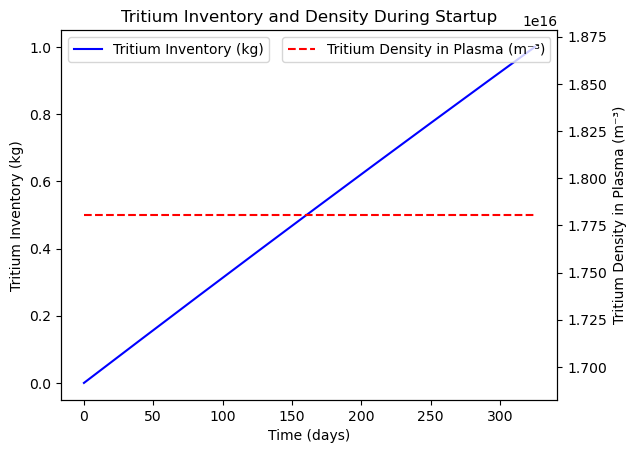

In [10]:
# use solve_ivp to plot the time evolution of tritium inventory and density
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def tritium_ode(t, y):
    N_T = y[0]
    dN_Tdt = Tdot_tot - N_T * lambda_T
    return [dN_Tdt]

# initial condition: zero tritium inventory
N_T0 = 0.0

sol = solve_ivp(tritium_ode, [0, t_startup*1.1], [N_T0], dense_output=True, events=lambda t, y: y[0] - N_ST)

# time points for evaluation
t_eval = np.linspace(0, t_startup, 1000)
y_eval = sol.sol(t_eval)[0]

# extract tritium inventory and density
N_T = y_eval
n_T_vect = n_T*np.ones_like(t_eval)  # constant density for this simplified model

# plot results
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(t_eval/86400, N_T * tritium_mass, 'b-', label='Tritium Inventory (kg)')
ax2.plot(t_eval/86400, n_T_vect, 'r--', label='Tritium Density in Plasma (m⁻³)')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Tritium Inventory (kg)')
ax2.set_ylabel('Tritium Density in Plasma (m⁻³)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Tritium Inventory and Density During Startup')
plt.show()

## Block 3: Calculate Power, Energy, and Unrealized Gains

Calculate fusion powers, Q factors, net energy, and economic metrics.

In [11]:
# Calculate fusion power from DD→T+p reaction
if sol_success:
    Pf_DDp = n_D**2 * sigmav_DD_p * V_plasma * E_DDp
else:
    Pf_DDp = np.nan

# Calculate fusion power from DD→³He+n reaction
if sol_success:
    Pf_DDn = n_D**2 * sigmav_DD_n * V_plasma * E_DDn
else:
    Pf_DDn = np.nan

# Total DD fusion power
if sol_success:
    Pf_DD = Pf_DDp + Pf_DDn
    print("Total DD fusion power")
    print(f"  P_f,DD = P_f,DDp + P_f,DDn")
    print(f"         = {Pf_DDp:.2e} + {Pf_DDn:.2e}")
    print(f"         = n_D^2 * ⟨σv⟩_DDp * V_plasma * E_DDp + n_D^2 * ⟨σv⟩_DDn * V_plasma * E_DDn")
    print(f"         = {n_D:.2e}^2 * {sigmav_DD_p:.2e} * {V_plasma} * {E_DDp:.2e} + {n_D:.2e}^2 * {sigmav_DD_n:.2e} * {V_plasma} * {E_DDn:.2e}")
    print(f"         = {Pf_DD:.2e} W = {Pf_DD/1e6:.2f} MW")
else:
    Pf_DD = np.nan
    print("P_f,DD = NaN (infeasible)")
print()

# Calculate DT fusion power (from built-up tritium)
if sol_success:
    Pf_DD_DT = n_D * n_T * sigmav_DT * V_plasma * E_DT
    print("DT fusion power (from accumulated tritium)")
    print(f"  P_f,DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"         = {n_D:.2e} * {n_T:.2e} * {sigmav_DT:.2e} * {V_plasma} * {E_DT:.2e}")
    print(f"         = {Pf_DD_DT:.2e} W = {Pf_DD_DT/1e6:.2f} MW")
else:
    Pf_DD_DT = np.nan
    print("P_f,DT = NaN (infeasible)")
print()
# Calculate D-³He fusion power
if sol_success:
    Pf_DD_DHe3 = n_D * n_He3 * sigmav_DHe3 * V_plasma * E_DHe3
    print("D-³He fusion power")
    print(f"  P_f,DHe3 = n_D * n_He3 * ⟨σv⟩_DHe3 * V_plasma * E_DHe3")
    print(f"           = {n_D:.2e} * {n_He3:.2e} * {sigmav_DHe3:.2e} * {V_plasma} * {E_DHe3:.2e}")
    print(f"           = {Pf_DD_DHe3:.2e} W = {Pf_DD_DHe3/1e6:.2f} MW")
else:
    Pf_DD_DHe3 = np.nan
    print("P_f,DHe3 = NaN (infeasible)")
print()
# Total fusion power during DD startup
if sol_success:
    Pf_DD_tot = Pf_DD + Pf_DD_DT + Pf_DD_DHe3
    print("Total fusion power during DD startup")
    print(f"  P_f,DD_tot = P_f,DD + P_f,DT + P_f,DHe3")
    print(f"             = {Pf_DD:.2e} + {Pf_DD_DT:.2e} + {Pf_DD_DHe3:.2e}")
    print(f"             = {Pf_DD_tot:.2e} W = {Pf_DD_tot/1e6:.2f} MW")
else:
    Pf_DD_tot = np.nan
    print("P_f,DD_tot = NaN (infeasible)")
print()

Total DD fusion power
  P_f,DD = P_f,DDp + P_f,DDn
         = 3.59e+06 + 2.74e+06
         = n_D^2 * ⟨σv⟩_DDp * V_plasma * E_DDp + n_D^2 * ⟨σv⟩_DDn * V_plasma * E_DDn
         = 1.70e+20^2 * 1.28e-24 * 150.0 * 6.46e-13 + 1.70e+20^2 * 1.21e-24 * 150.0 * 5.24e-13
         = 6.33e+06 W = 6.33 MW

DT fusion power (from accumulated tritium)
  P_f,DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT
         = 1.70e+20 * 1.78e+16 * 2.41e-22 * 150.0 * 2.82e-12
         = 3.08e+05 W = 0.31 MW

D-³He fusion power
  P_f,DHe3 = n_D * n_He3 * ⟨σv⟩_DHe3 * V_plasma * E_DHe3
           = 1.70e+20 * 1.75e+16 * 8.92e-25 * 150.0 * 2.93e-12
           = 1.16e+03 W = 0.00 MW

Total fusion power during DD startup
  P_f,DD_tot = P_f,DD + P_f,DT + P_f,DHe3
             = 6.33e+06 + 3.08e+05 + 1.16e+03
             = 6.64e+06 W = 6.64 MW



In [12]:
# Calculate equivalent DT fusion power (for comparison)
# This is the power if we had 50-50 D-T plasma from the start
if sol_success:
    Pf_DT_eq = (n_tot / 2)**2 * sigmav_DT * V_plasma * E_DT
    print("Equivalent DT fusion power (50-50 D-T plasma)")
    print(f"  P_f,DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"            = ({n_tot:.2e}/2)² * {sigmav_DT:.2e} * {V_plasma} * {E_DT:.2e}")
    print(f"            = {Pf_DT_eq:.2e} W = {Pf_DT_eq/1e6:.2f} MW")
else:
    Pf_DT_eq = np.nan
    print("P_f,DT_eq = NaN (infeasible)")
print()

Equivalent DT fusion power (50-50 D-T plasma)
  P_f,DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT
            = (1.70e+20/2)² * 2.41e-22 * 150.0 * 2.82e-12
            = 7.35e+08 W = 735.10 MW



# Calculate P_aux and P_aux_DT_eq

In [13]:
# ============================================================================
# CALCULATE P_aux(t) ALONG THE SOLUTION TRAJECTORY
# ============================================================================
from src.physics.power_balance import calculate_P_aux_from_power_balance
    
if sol_success and P_aux is None:
    
    P_aux = calculate_P_aux_from_power_balance(
            n_T, n_D, T_i, V_plasma,
            sigmav_DD_p, sigmav_DD_n, sigmav_DT, tau_p_T
        )
    
    print(f"  P_aux = {P_aux:.2e} W = {P_aux/1e6:.2f} MW")
    print()
    
    # Check if plasma ever reaches ignition (P_aux < 0)
    if P_aux <= 0:
        print("  🔥 Plasma reaches ignition"   )
    else:
        print("  ⚠️  Plasma does not reach ignition during startup")
    print()
if sol_success and P_aux_DT_eq is None:    
    P_aux_DT_eq = calculate_P_aux_from_power_balance(
            n_tot/2, n_tot/2, T_i, V_plasma,
            sigmav_DD_p, sigmav_DD_n, sigmav_DT, tau_p_T
        )
    
    print(f"  P_aux_eq = {P_aux_DT_eq:.2e} W = {P_aux_DT_eq/1e6:.2f} MW")
    print()
    
else:
    print("Cannot calculate P_aux evolution (infeasible solution)")
    



  P_aux = 1.79e+08 W = 179.05 MW

  ⚠️  Plasma does not reach ignition during startup

  P_aux_eq = 3.45e+07 W = 34.51 MW



In [14]:
# Calculate Q factor for DD startup
# Q = (Fusion Power - Auxiliary Power) / Auxiliary Power
if sol_success:
    Q_DD = (Pf_DD_tot - P_aux) / P_aux
    print("Q factor for DD startup")
    print(f"  Q_DD = (P_f,DD_tot - P_aux) / P_aux")
    print(f"       = ({Pf_DD_tot:.2e} - {P_aux:.2e}) / {P_aux:.2e}")
    print(f"       = {Q_DD:.4f}")
    if Q_DD > 1:
        print(f"  ✓ Net energy gain (Q > 1)")
    else:
        print(f"  ✗ Net energy loss (Q < 1)")
else:
    Q_DD = np.nan
    print("Q_DD = NaN (infeasible or P_aux = 0)")
print()

# Calculate Q factor for equivalent DT operation
if sol_success and P_aux_DT_eq > 0:
    Q_DT_eq = (Pf_DT_eq - P_aux_DT_eq) / P_aux_DT_eq
    print("Q factor for equivalent DT operation")
    print(f"  Q_DT_eq = (P_f,DT_eq - P_aux_DT_eq) / P_aux_DT_eq")
    print(f"          = ({Pf_DT_eq:.2e} - {P_aux_DT_eq:.2e}) / {P_aux_DT_eq:.2e}")
    print(f"          = {Q_DT_eq:.4f}")
else:
    Q_DT_eq = np.nan
    print("Q_DT_eq = NaN (infeasible or P_aux_DT_eq = 0)")
print()

Q factor for DD startup
  Q_DD = (P_f,DD_tot - P_aux) / P_aux
       = (6.64e+06 - 1.79e+08) / 1.79e+08
       = -0.9629
  ✗ Net energy loss (Q < 1)

Q factor for equivalent DT operation
  Q_DT_eq = (P_f,DT_eq - P_aux_DT_eq) / P_aux_DT_eq
          = (7.35e+08 - 3.45e+07) / 3.45e+07
          = 20.2981



In [15]:
# Calculate net electric power during DD startup
if sol_success:
    P_e_net = capacity_factor * (eta_th * Pf_DD_tot - P_aux)
    print("Net electric power during DD startup")
    print(f"  P_e,net = capacity_factor * (η_th * P_f,DD_tot - P_aux)")
    print(f"          = {capacity_factor} * ({eta_th} * {Pf_DD_tot:.2e} - {P_aux:.2e})")
    print(f"          = {P_e_net:.2e} W = {P_e_net/1e6:.2f} MW")
    if P_e_net > 0:
        print(f"  ✓ Net electricity production")
    else:
        print(f"  ✗ Net electricity consumption")
else:
    P_e_net = np.nan
    print("P_e,net = NaN (infeasible)")
print()

# Calculate net electric power for equivalent DT operation
if sol_success:
    P_e_net_DT_eq = capacity_factor * (eta_th * Pf_DT_eq - P_aux_DT_eq)
    print("Net electric power for equivalent DT operation")
    print(f"  P_e,net_DT_eq = capacity_factor * (η_th * P_f,DT_eq - P_aux_DT_eq)")
    print(f"                = {capacity_factor} * ({eta_th} * {Pf_DT_eq:.2e} - {P_aux_DT_eq:.2e})")
    print(f"                = {P_e_net_DT_eq:.2e} W = {P_e_net_DT_eq/1e6:.2f} MW")
else:
    P_e_net_DT_eq = np.nan
    print("P_e,net_DT_eq = NaN (infeasible)")
print()

Net electric power during DD startup
  P_e,net = capacity_factor * (η_th * P_f,DD_tot - P_aux)
          = 0.8 * (0.4 * 6.64e+06 - 1.79e+08)
          = -1.41e+08 W = -141.12 MW
  ✗ Net electricity consumption

Net electric power for equivalent DT operation
  P_e,net_DT_eq = capacity_factor * (η_th * P_f,DT_eq - P_aux_DT_eq)
                = 0.8 * (0.4 * 7.35e+08 - 3.45e+07)
                = 2.08e+08 W = 207.62 MW



In [16]:
# Calculate total net energy during DD startup
if sol_success:
    E_e_net_DD = P_e_net * t_startup
    print("Total net energy produced during DD startup")
    print(f"  E_e,net_DD = P_e,net * t_startup")
    print(f"             = {P_e_net:.2e} W * {t_startup:.2e} s")
    print(f"             = {E_e_net_DD:.2e} J")
    print(f"             = {E_e_net_DD*joule_to_GWh:.2f} GWh")
else:
    E_e_net_DD = np.nan
    print("E_e,net_DD = NaN (infeasible)")
print()

# Calculate total net energy for equivalent DT operation
if sol_success:
    E_e_net_DT_eq = P_e_net_DT_eq * t_startup
    print("Total net energy if we had DT from the start")
    print(f"  E_e,net_DT_eq = P_e,net_DT_eq * t_startup")
    print(f"                = {P_e_net_DT_eq:.2e} W * {t_startup:.2e} s")
    print(f"                = {E_e_net_DT_eq:.2e} J")
    print(f"                = {E_e_net_DT_eq*joule_to_GWh:.2f} GWh")
else:
    E_e_net_DT_eq = np.nan
    print("E_e,net_DT_eq = NaN (infeasible)")
print()

Total net energy produced during DD startup
  E_e,net_DD = P_e,net * t_startup
             = -1.41e+08 W * 2.81e+07 s
             = -3.97e+15 J
             = -1101.66 GWh

Total net energy if we had DT from the start
  E_e,net_DT_eq = P_e,net_DT_eq * t_startup
                = 2.08e+08 W * 2.81e+07 s
                = 5.83e+15 J
                = 1620.83 GWh



In [17]:
# Calculate LOST ENERGY
# This is the energy we could have had with DT, but didn't get with DD startup
if sol_success:
    E_lost = E_e_net_DT_eq - E_e_net_DD
    print("Energy lost due to DD startup (compared to DT)")
    print(f"  E_lost = E_e,net_DT_eq - E_e,net_DD")
    print(f"         = {E_e_net_DT_eq:.2e} - {E_e_net_DD:.2e}")
    print(f"         = {E_lost:.2e} J")
    print(f"         = {E_lost*joule_to_GWh:.2f} GWh")
    if E_lost > 0:
        print(f"  ⚠️  Lost energy: DT would have produced MORE")
    else:
        print(f"  ✓ No lost energy: DD produced as much or more than DT")
else:
    E_lost = np.nan
    print("E_lost = NaN (infeasible)")
print()

Energy lost due to DD startup (compared to DT)
  E_lost = E_e,net_DT_eq - E_e,net_DD
         = 5.83e+15 - -3.97e+15
         = 9.80e+15 J
         = 2722.49 GWh
  ⚠️  Lost energy: DT would have produced MORE



In [18]:
# Calculate UNREALIZED GAINS (economic impact)
# This is the monetary value of the lost energy
if sol_success:
    unrealized_gains = E_lost * price_of_electricity
    print("Unrealized gains (economic cost of DD startup)")
    print(f"  Unrealized gains = E_lost * price_of_electricity")
    print(f"                   = {E_lost:.2e} J * {price_of_electricity:.2e} $/J")
    print(f"                   = {unrealized_gains:.2e} $")
    print(f"                   = {unrealized_gains/1e6:.2f} M$")
    print(f"\n  💰 This are the unrealized gains in electric energy production of DD startup vs. having tritium from day 1")
else:
    unrealized_gains = np.nan
    print("Unrealized gains = NaN (infeasible)")
print()

Unrealized gains (economic cost of DD startup)
  Unrealized gains = E_lost * price_of_electricity
                   = 9.80e+15 J * 6.94e-08 $/J
                   = 6.81e+08 $
                   = 680.62 M$

  💰 This are the unrealized gains in electric energy production of DD startup vs. having tritium from day 1



In [19]:
#compute cost of tritium
c_T = unrealized_gains/I_target
print(f"cost of tritium = {c_T/1e6:.2f} M$")

cost of tritium = 680.62 M$


## Final Summary

Complete overview of the computation results.

In [20]:
print("\n" + "="*80)
print("FINAL COMPUTATION SUMMARY")
print("="*80)

print("\n📊 INPUT PARAMETERS:")
print(f"  Plasma volume: {V_plasma} m³")
print(f"  Ion temperature: {T_i} keV")
print(f"  Total density: {n_tot:.2e} m⁻³")
print(f"  Target inventory: {I_target} kg tritium")
print(f"  Auxiliary power: {P_aux/1e6} MW")

print("\n⏱️  STARTUP TIME:")
if sol_success:
    print(f"  t_startup = {t_startup:.2e} s")
    print(f"            = {t_startup/86400:.2f} days")
    print(f"            = {t_startup/(365.25*86400):.4f} years")
    print(f"  Status: ✅ SUCCESS")
else:
    print(f"  t_startup = ∞")
    print(f"  Status: ❌ INFEASIBLE (tritium production cannot overcome decay)")

if sol_success:
    print("\n⚡ PLASMA COMPOSITION:")
    print(f"  n_D = {n_D:.2e} m⁻³")
    print(f"  n_T = {n_T:.2e} m⁻³ ({100*n_T/n_D:.4f}% of deuterium)")
    print(f"  n_He3 = {n_He3:.2e} m⁻³ ({100*n_He3/n_D:.4f}% of deuterium)")
    
    print("\n🔥 FUSION PERFORMANCE:")
    print(f"  Total DD fusion power: {Pf_DD_tot/1e6:.2f} MW")
    print(f"  Equivalent DT power: {Pf_DT_eq/1e6:.2f} MW")
    print(f"  Q_DD = {Q_DD:.4f}")
    print(f"  Q_DT_eq = {Q_DT_eq:.4f}")
    
    print("\n💡 NET ELECTRICITY:")
    print(f"  During DD startup: {P_e_net/1e6:.2f} MW")
    print(f"  If DT from start: {P_e_net_DT_eq/1e6:.2f} MW")
    
    print("\n📉 ENERGY LOSSES:")
    print(f"  Energy lost: {E_lost/joule_to_GWh:.2f} GWh")
    print(f"  Duration: {t_startup/86400:.2f} days")
    
    print("\n💰 ECONOMIC IMPACT:")
    print(f"  Unrealized gains: {unrealized_gains/1e6:.2f} M$")
    print(f"  Cost per day: {(unrealized_gains/(t_startup/86400))/1e6:.2f} M$/day")


FINAL COMPUTATION SUMMARY

📊 INPUT PARAMETERS:
  Plasma volume: 150.0 m³
  Ion temperature: 14.0 keV
  Total density: 1.70e+20 m⁻³
  Target inventory: 1 kg tritium
  Auxiliary power: 179.05453846680868 MW

⏱️  STARTUP TIME:
  t_startup = 2.81e+07 s
            = 325.28 days
            = 0.8906 years
  Status: ✅ SUCCESS

⚡ PLASMA COMPOSITION:
  n_D = 1.70e+20 m⁻³
  n_T = 1.78e+16 m⁻³ (0.0105% of deuterium)
  n_He3 = 1.75e+16 m⁻³ (0.0103% of deuterium)

🔥 FUSION PERFORMANCE:
  Total DD fusion power: 6.64 MW
  Equivalent DT power: 735.10 MW
  Q_DD = -0.9629
  Q_DT_eq = 20.2981

💡 NET ELECTRICITY:
  During DD startup: -141.12 MW
  If DT from start: 207.62 MW

📉 ENERGY LOSSES:
  Energy lost: 35283498403070365719301455872.00 GWh
  Duration: 325.28 days

💰 ECONOMIC IMPACT:
  Unrealized gains: 680.62 M$
  Cost per day: 2.09 M$/day
